# Discriminative Learning Algorithms 判别式算法
## Linear Regression 线性回归
当我们有了一些可能存在线性相关的数据时,我们可以使用线性函数来进行拟合
比如:
$$h(x) = \sum_{j=0}^{n}\theta _j x_j$$
我们让$x_0=1$这时,$h(x)$可以表示一个线性函数(liner function),在数学上被称为仿射函数(affine function),因为存在$\theta_0$作为截距可以调成初始函数值.

我们称$\theta$为参数(parameters),通过学习算法.我们选择$\theta$

类似的,我们用
- $m$表示训练内容量(the number of training examples)
- $x$表示输入内容(inputs),也被称为特征(features)
- $y$表示输出(outputs),也被称作目标变量(target variable)
- $(x,y)$表示一个训练例子(training example)
- $(x^{(i)},y^{(i)})$表示第$i$个训练例子(the $i^{th}$ training example)
- $n$表示监督学习(supervised learning)中总的特征数量
### Gradient Descent 梯度下降
#### Batch Gradient Descent(BGD) 批次梯度下降
如何找到一个好的$\theta$呢?
> $s.t. \; h(x) \approx y \; for \; training \; examples$

我们可以使用记号$h_\theta (x)$来强调$h$同时依赖于参数与特征,当然两者没有本质区别

为此我们,我们可以最小化
$$(h_\theta (x)- y)^2$$
对于$m$个训练数,也就求得$minJ(\theta)$.其中,$J(\theta)$为:
$$J(\theta)=\frac{1}{2}\sum_{i=1}^{m}(h_\theta (x)- y)^2 $$
Wu声称$\frac{1}{2}$是为了使得求导后更加容易算,而是否有$\frac{1}{2}$并不影响最小值~~我感觉不是很有必要~~

之所以使用平方误差,对应着高斯分布,具体将在后面线性回归的推广处详解

接下来我们介绍梯度下降算法
- 从某个$\theta$值开始,比如$\theta=\vec{0}$就是一个很好的初始点
- 不断改变$\theta$的数值,来**减少**$J(\theta)$
- 注意到该过程像是在寻找所有方向中可以最快"下坡"的路,走一步,然后重复,最终获得一个局部最优的解
- 注意到上述过程类似于数学中的梯度($\nabla$),于是我们用如下公式定义:
$$\theta _j := \theta _j - \alpha \frac{\partial} {\partial \theta _j} J(\theta)\tag{1}$$
其中,
- :=代表赋值(assignment)
- $\alpha$ 表示学习率(learning rate)
接下来,我们要展开$J(\theta)$好好算一算
$$
\begin{aligned}
\frac{\partial}{\partial \theta_{j}} J(\theta) &= \frac{\partial}{\partial \theta_{j}} \frac{1}{2}\left(h_{\theta}(x)-y\right)^{2} \\
&= 2 \cdot \frac{1}{2}\left(h_{\theta}(x)-y\right) \cdot \frac{\partial}{\partial \theta_{j}}\left(h_{\theta}(x)-y\right) \\
&= \left(h_{\theta}(x)-y\right) \cdot \frac{\partial}{\partial \theta_{j}}\left(\sum_{i=0}^{n} \theta_{i} x_{i}-y\right)       \tag{2}\\
&= \left(h_{\theta}(x)-y\right) x_{j}
\end{aligned}
$$
对于(2)中不同的$j$取值,只有对应的$\theta _j x_j$对偏导有贡献并计算得到$x_j$,由此可以得到最终答案~~似乎乘上0.5的确更好看~~

带回公式(1)可得:
$$
\theta _j := \theta _j - \sum _{i=1}^{m}\alpha (h_\theta (x^{(i)}))-y^{(i)}) x_j^{(i)}\tag{3}
$$
为使公式满足对于m个数据集的总操作,我们加上$\sum$来完善

综上,不断重复上述操作(3)直至收敛,其中$j=1,2,\cdots,n$,其中$n$为特征($x$)的数量

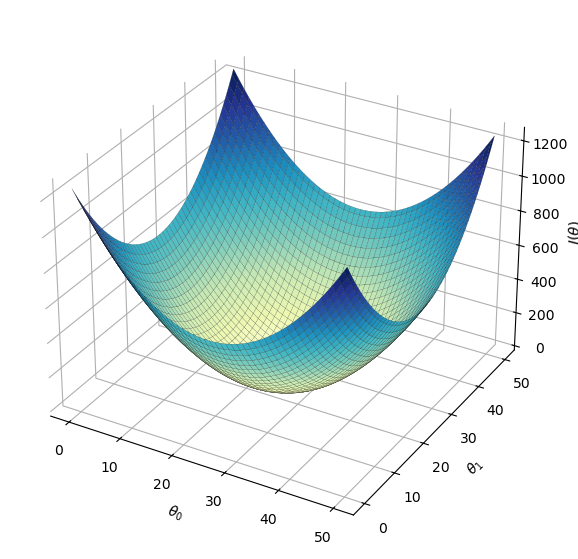

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

theta0 = np.linspace(0, 50, 100)
theta1 = np.linspace(0, 50, 100)
T0, T1 = np.meshgrid(theta0, theta1)
J = (T0 - 25)**2 + (T1 - 25)**2

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# 关键在这里：
# cmap='YlGnBu' (黄绿蓝) 或者 'GnBu' (绿蓝) 会非常亮
# antialiased=True 让网格看起来更细腻
surf = ax.plot_surface(T0, T1, J, cmap='YlGnBu', 
                       edgecolor='black', linewidth=0.1, antialiased=True)

ax.set_xlabel(r'$\theta_0$')
ax.set_ylabel(r'$\theta_1$')
ax.set_zlabel(r'$J(\theta)$')

# 调整背景色为白色，看起来会更亮
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))

plt.show()

上方是函数$J(\theta)$的图像,我们发现,如果按照平方误差来定义,$J(\theta)$就是一个二次函数(上方的大碗),这意味着该函数不存在局部最优,或者说,局部最优就是全局最优解.接下来,我们看向水平切片的边缘:

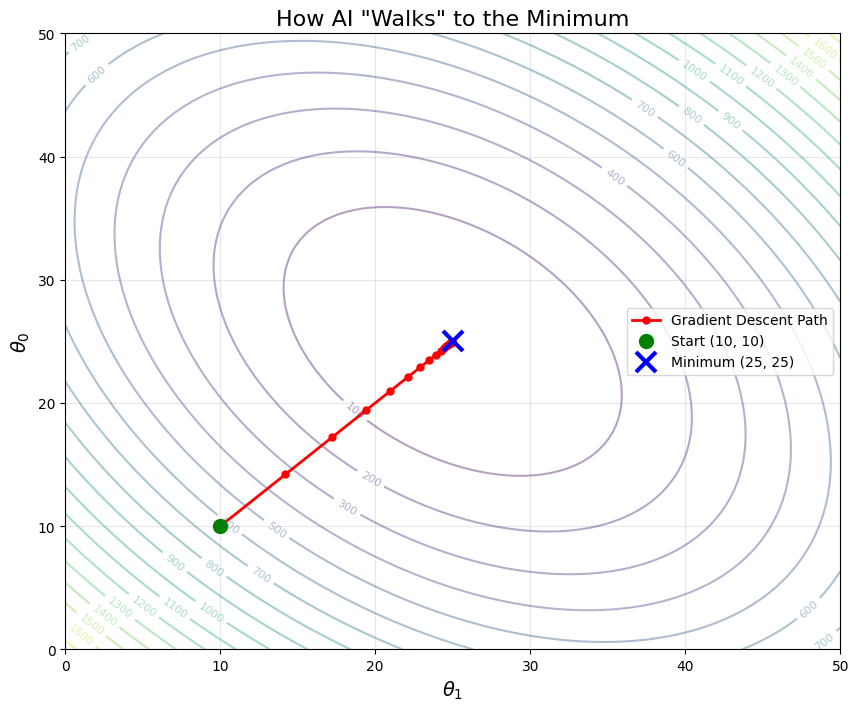

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 定义代价函数 J(theta0, theta1) 和它的梯度 (Nabla 算子)
# 为了配合之前的倾斜椭圆，我们使用这个二次型函数
def cost_function(t0, t1):
    return (t0 - 25)**2 + (t1 - 25)**2 + 0.8*(t0 - 25)*(t1 - 25)

def get_gradient(t0, t1):
    # 手写偏导数 (根据上面的公式求导)
    grad_t0 = 2 * (t0 - 25) + 0.8 * (t1 - 25)
    grad_t1 = 2 * (t1 - 25) + 0.8 * (t0 - 25)
    return grad_t0, grad_t1

# 2. 梯度下降算法实现
theta0_start, theta1_start = 10.0, 10.0 # 初始点（山坡上）
learning_rate = 0.1                    # 学习率 alpha
iterations = 20                         # 迭代步数

# 用列表记录每一步的路径
path_t0 = [theta0_start]
path_t1 = [theta1_start]

t0, t1 = theta0_start, theta1_start
for _ in range(iterations):
    g0, g1 = get_gradient(t0, t1)
    t0 = t0 - learning_rate * g0 # 核心公式
    t1 = t1 - learning_rate * g1
    path_t0.append(t0)
    path_t1.append(t1)

# 3. 绘图 (等高线 + 路径)
t0_range = np.linspace(0, 50, 100)
t1_range = np.linspace(0, 50, 100)
T1, T0 = np.meshgrid(t1_range, t0_range)
J = cost_function(T0, T1)

plt.figure(figsize=(10, 8))
# 画出底图：等高线
cp = plt.contour(T1, T0, J, levels=20, cmap='viridis', alpha=0.4)
plt.clabel(cp, inline=True, fontsize=8)

# 画出路径：用红色的点和线连接
plt.plot(path_t1, path_t0, 'r-o', markersize=5, linewidth=2, label='Gradient Descent Path')

# 标记起点和终点
plt.plot(path_t1[0], path_t0[0], 'go', markersize=10, label='Start (10, 10)')
plt.plot(25, 25, 'bx', markersize=15, markeredgewidth=3, label='Minimum (25, 25)')

plt.xlabel(r'$\theta_1$', fontsize=14)
plt.ylabel(r'$\theta_0$', fontsize=14)
plt.title('How AI "Walks" to the Minimum', fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

图片底部的椭圆就是函数的水平切片的边缘,我让ai绘制了类似于梯度下降的算法,我们会注意到两件事情:
1. 每次"下降",路线和水平切片的边缘都是正交的
2. 鉴于不存在局部最优,最终算法会收敛到全局最小值,也就是"碗底"

接下来我们讨论$\alpha$的选取,如果$\alpha$特别的大,可能会直接越过最小值,而过小的话,迭代次数会特别大,意味着极慢的运行速度,一般通过多次实验来确定比较好的$\alpha$

 我们还可以称上述"梯度下降"为"batch gradient descent"(批次梯度下降),这意味着在面对大数据(如一个美国的房价数据),我们可以采取将其分为多批次少量的数据集,也就是所谓的"batch"

注意到该算法有一个显著的缺点:$\sum$ 被使用,这意味着如果式子(3)中的m特别的大,我们需要扫描整个数据集来进行一步下降,而算法又是高度依赖多次下降以达到收敛,所以每一步都比较慢,下面我们会介绍另一个算法:

#### Stochastic Gradient Descent 随机梯度下降法 

不同于扫描整个数据集来更新$\theta$,我们一般采取以下方法来进行更新:

**Repeat** {
  
  For $i = 1$ to $m$:
  $$ \theta_j := \theta_j - \alpha (h_\theta(x^{(i)}) - y^{(i)}) x_j^{(i)} $$
}

对于SGD,我们在每遇到一个数据m时就对$\theta$进行一次更新,实际上,不同于BGD,SGD的收敛路线是带有噪音的,并且虽然全局上向最低水平收敛,但实际上会在最低点附近震荡而非收敛后停止,但是在大数据集下我们以更快的方式取得了进展,并且wu在回答某同学提问中提到,在较大的数据下,我们极少使用BGD,而是通过不断减小$\alpha$也就是SGD的学习率来减小震荡所带来的误差。

当然,梯度下降法并不是只用来解决线性回归,只是由于线性回归不存在局部最优解使得该方法表现较为出色,然而对于纯线性回归,我们有另外一种手段:

### Normal Equation 正规方程
我们先给出如下定义:
#### 矩阵导数
$$
\nabla_A f(A) = \begin{bmatrix}
\frac{\partial f}{\partial A_{11}} & \frac{\partial f}{\partial A_{12}} & \dots & \frac{\partial f}{\partial A_{1n}} \\
\frac{\partial f}{\partial A_{21}} & \frac{\partial f}{\partial A_{22}} & \dots & \frac{\partial f}{\partial A_{2n}} \\
\vdots & \vdots & \ddots & \vdots \\
\frac{\partial f}{\partial A_{m1}} & \frac{\partial f}{\partial A_{m2}} & \dots & \frac{\partial f}{\partial A_{mn}}
\end{bmatrix}
$$
比如,

一个 $2 \times 2$ 的矩阵 $A = \begin{bmatrix} A_{11} & A_{12} \\ A_{21} & A_{22} \end{bmatrix}$

**函数**：$f(A) = A_{11} + A_{12}^2$

注意：这个函数只用到了 $A_{11}$ 和 $A_{12}$，与 $A_{21}$ 和 $A_{22}$ 无关（相当于它们的系数是 0）。
目标:

求 $\nabla_A f(A)$。

根据定义，我们需要对矩阵里的**每一个位置**分别求偏导数，然后把结果放回原来的位置。

计算过程：

1.  **左上角 ($A_{11}$)**：
    $$ \frac{\partial}{\partial A_{11}} (A_{11} + A_{12}^2) = 1 $$
    *(因为 $A_{11}$ 的导数是 1，后面的是常数)*

2.  **右上角 ($A_{12}$)**：
    $$ \frac{\partial}{\partial A_{12}} (A_{11} + A_{12}^2) = 2A_{12} $$
    *(因为 $A_{12}^2$ 的导数是 $2A_{12}$)*

3.  **左下角 ($A_{21}$)**：
    $$ \frac{\partial}{\partial A_{21}} (A_{11} + A_{12}^2) = 0 $$
    *(函数里根本没有 $A_{21}$，所以它是常数，导数为 0)*

4.  **右下角 ($A_{22}$)**：
    $$ \frac{\partial}{\partial A_{22}} (A_{11} + A_{12}^2) = 0 $$
    *(同理，导数为 0)*

拼装结果：

把上面算出来的 4 个数，按照它们在 $A$ 中原来的位置摆好：

$$
\nabla_A f(A) = \begin{bmatrix}
\frac{\partial f}{\partial A_{11}} & \frac{\partial f}{\partial A_{12}} \\
\frac{\partial f}{\partial A_{21}} & \frac{\partial f}{\partial A_{22}}
\end{bmatrix} = \begin{bmatrix}
1 & 2A_{12} \\
0 & 0
\end{bmatrix}
$$

这样做的目的主要是:
**如果我们对一个标量函数 $f$ 关于一个矩阵 $A$ 求导，那么结果（梯度）也是一个矩阵，而且形状必须和 $A$ 一模一样。**


在公式：
$$ A := A - \alpha \nabla_A f(A) $$
中,矩阵减法要求两个矩阵形状必须相同。所以，$\nabla_A f(A)$ 必须长得和 $A$ 一样，这样才能对应位置相减。

#### 矩阵的迹(trace)
给出一个矩阵$A$,满足$A\in \mathbb{R}^{n\times n}$,记:
$$\operatorname{tr} A=\sum^{n}_{i} A_{ii}$$
即对角线元素之和,对于迹有以下几个特点:
*  $\operatorname{tr} A=\operatorname{tr} A^{T}$
*  若$f(A)=\operatorname{tr}AB$,则$\nabla_{A}f(A)=B^{T}$
*  $\operatorname{tr}AB=\operatorname{tr}BA$
   这也意味着$\operatorname{tr}ABC=\operatorname{tr}CAB$,即在$\operatorname{tr}$运算下,对矩阵的左乘和右乘没有区别
*  $\nabla_A \text{tr}(A A^T C) = CA + C^T A$
   虽然我没有注意到,但是a接下来wu讲到,其实上述公式可以类比为二次函求导:
   对于$f(x) = c \cdot x^2$,有$\frac{d}{dx} f(x) = 2cx$
   而
   - 矩阵 $A$ 对应于标量 $x$
   - 常数矩阵 $C$ 对应于常数 $c$
   - 矩阵的“平方” $A A^T$ 对应于标量的平方 $x^2$
   - 有上一个公式,$A A^T C$其实等价于$C A A^T $
   矩阵求导法则 $\nabla_A \text{tr}(A A^T C)$ 本质上就是高中二次函数求导法则在矩阵世界中的一个推广。它描述了当自变量 $A$ 发生微小变化时，这个二次函数 $f(A)$ 的梯度(变化最快的方向)


对于线性回归问题,我们给出以下方程:
*  为获得$J(\theta)$的最小值,我们求:$$\nabla _\theta J(\theta)  \stackrel{\text{set}}{=}  \vec{0}$$               
怎么求呢?我们先设:

- **$\theta$ (参数向量)**: 一个 $n \times 1$ 的列向量。
  $$ \theta = \begin{bmatrix} \theta_1 \\ \theta_2 \\ \vdots \\ \theta_n \end{bmatrix} $$

- **$x^{(i)}$ (第 $i$ 个样本)**: 一个 $n \times 1$ 的列向量。因此，转置 $(x^{(i)})^T$ 是一个 $1 \times n$ 的行向量。预测值 $h_\theta(x^{(i)}) = (x^{(i)})^T \theta$ 是一个标量。

- **$X$ (设计矩阵 Design Matrix)**: 这是一个 $m \times n$ 的矩阵，它的每一**行**是一个训练样本的转置。
  $$ X = \begin{bmatrix} — (x^{(1)})^T — \\ — (x^{(2)})^T — \\ \vdots \\ — (x^{(m)})^T — \end{bmatrix} $$

- **$y$ (标签向量)**: 这是一个 $m \times 1$ 的列向量，包含了所有样本的真实值。
  $$ y = \begin{bmatrix} y^{(1)} \\ y^{(2)} \\ \vdots \\ y^{(m)} \end{bmatrix} $$

**步骤一：计算 $X\theta$**
将 $m \times n$ 的矩阵 $X$ 乘以 $n \times 1$ 的向量 $\theta$，结果是一个 $m \times 1$ 的列向量：
$$ X\theta = \begin{bmatrix} (x^{(1)})^T \theta \\ (x^{(2)})^T \theta \\ \vdots \\ (x^{(m)})^T \theta \end{bmatrix} = \begin{bmatrix} h_\theta(x^{(1)}) \\ h_\theta(x^{(2)}) \\ \vdots \\ h_\theta(x^{(m)}) \end{bmatrix} $$
*直观理解：$X\theta$ 就是一个包含了模型对所有 $m$ 个样本预测值的列向量。*

**步骤二：计算误差向量 $X\theta - y$**
将预测值列向量减去真实值列向量，结果依然是一个 $m \times 1$ 的列向量（我们设它为 $z$）：
$$ z = X\theta - y = \begin{bmatrix} h_\theta(x^{(1)}) - y^{(1)} \\ h_\theta(x^{(2)}) - y^{(2)} \\ \vdots \\ h_\theta(x^{(m)}) - y^{(m)} \end{bmatrix} $$
*直观理解：这个列向量里的每一个元素，就是对应样本的“预测误差”。*

**步骤三：利用向量内积消去 $\sum$**
根据线性代数的基础知识，一个列向量 $z$ 自身的内积 $z^T z$ 等于它各个元素的平方和：
$$ z^T z = \begin{bmatrix} z_1 & z_2 & \dots & z_m \end{bmatrix} \begin{bmatrix} z_1 \\ z_2 \\ \vdots \\ z_m \end{bmatrix} = \sum_{i=1}^{m} z_i^2 $$

**步骤四：代入我们的误差向量 $z$**
既然 $z_i = h_\theta(x^{(i)}) - y^{(i)}$，那么：
$$ (X\theta - y)^T (X\theta - y) = \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})^2 $$

最后，在等式两边同时乘以 $\frac{1}{2}$，推导完成！
$$ \frac{1}{2} (X\theta - y)^T (X\theta - y) = \frac{1}{2} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})^2 = J(\theta) $$

那么,
$$
\begin{align*}
\nabla_{\theta} J(\theta) 
&= \nabla_\theta\frac{1}{2} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})^2 \\
&= \nabla_{\theta} \frac{1}{2} (X\theta - y)^T (X\theta - y)\\
&= \frac{1}{2} \nabla_{\theta} (\theta^T X^T X \theta - \theta^T X^T y - y^T X \theta + y^T y)\\
&= \frac{1}{2} \nabla_{\theta} \operatorname{tr} (\theta^T X^T X \theta - \theta^T X^T y- y^T X \theta + y^T y)  \tag{1} \\
&= \frac{1}{2} \nabla_{\theta} (\operatorname{tr} \theta^T X^T X \theta - 2 \operatorname{tr} y^T X \theta)\\
&= \frac{1}{2} (X^T X \theta + X^T X \theta - 2 X^T y)\\
&= X^T X \theta - X^T y
\end{align*}  \tag{2}$$
我们发现,$(1)$处"凭空"多了一个$\operatorname{tr}$,这是因为表达式就是一个标量,引入一个trace可以有效的简化运算过程
而$(2)$在移项后就得到:
$$X^T X \theta = X^T y$$
即正规方程,由此解得:$$\theta=(X^T X)^{-1}X^Ty$$









### Locally Weighted Regression局部加权回归
局部加权回归是一种线性回归的修正,可以使其拟合非线性的函数    
首先给出一个术语上的区分:
- 对于比如线性回归,我们将这种**拟合一组固定的参数**(即$\theta_i$)的计算方法称为参数化学习算法(parametric learning algorithm)                        
- 而当一个算法的数据/参数数量与数据规模呈线性增长时,我们称其为非参数化学习算法(non-parametric learning algorithm),比如所谓局部加权回归
显而易见的,这种算法对于大数据集相当不友好  
下面给出定义:
$$ \sum_{i=1}^{m} w^{(i)} (y^{(i)} - \theta^T x^{(i)})^2 $$
不同于标准线性回归的核心目标函数,我们加入了权重函数(Weighting function)$w^{(i)}$,也就是对于不同的样本点,权重是不同的,而$\omega$为:
$$ w^{(i)} = \exp \left( - \frac{(x^{(i)} - x)^2}{2\tau^{2}} \right) $$
其中,$\tau$决定了这个高斯钟的宽度,改变它可以决定在多宽的范围里寻找
*   **情况 A：当训练样本 $x^{(i)}$ 离预测点 $x$ 很“近”时**
    *   两者的差值 $|x^{(i)} - x|$ 接近于 0。
    *   平方之后 $\approx 0$。
    *   代入公式：$w^{(i)} \approx \exp(0) = e^0 = 1$。
    *   **结论**：这个样本的权重是 1。在拟合回归线时，我们**极其重视**这个样本的误差。

*   **情况 B：当训练样本 $x^{(i)}$ 离预测点 $x$ 很“远”时**
    *   两者的差值 $|x^{(i)} - x|$ 是一个很大的数。
    *   带负号的指数项：$w^{(i)} \approx \exp(-\text{一个大数})$。
    *   $e$ 的负无穷大次方接近于 0。所以 $w^{(i)} \approx 0$。
    *   **结论**：这个样本的权重是 0。在拟合回归线时，我们**完全无视**这个样本的误差。
也就是说,每次来一个新的查询点 $x$，算法都会以 $x$ 为中心，给周围的数据打分（离得近的分数高 $w \approx 1$，离得远的分数低 $w \approx 0$）。然后**只用分数高的数据**临时拟合出一条直线，算出预测值。预测完后，这条直线就扔了。这意味很强的灵活性,无论多复杂的非线性曲线都能拟合得很好，不需要提前设定多项式的阶数。但是这也呼应了之前的定义中暴露的缺点,计算成本极高!

总结,在标准的线性回归中，我们试图用**一条全局的直线**去拟合所有的数据。但如果数据分布比较复杂（比如呈波浪形），一条直线根本拟合不好（欠拟合/Underfitting）
解决方法就是既然一条直线拟合不了所有数据，那当我们想预测某个点 $x$ 的值时，我们**只看 $x$ 附近的数据**，在 $x$ 的局部范围内拟合出一条直线即可。那些离 $x$ 很远的数据，我们就当它们不存在



### Why least squares?为什么是二次幂?
我们将先进行如下假设:
对于比如房价$y^{(i)}$,定义为:
$$y(i)=\theta^{T}x^{(i)}+\epsilon{(i)}$$
其中$\epsilon$为未经建模的随机噪声,该情境下就是房价为面积和卧室数量的线性组合加上一个可能和个体有关的特殊情况

我们再假设$\epsilon$满足:$\epsilon\sim\mathcal{N}(0, \sigma^2)$,也就是高斯分布

<details>
  <summary>why guass</summary>
  大量不确定性因素在中心极限定理 (CLT)的影响下会接近于高斯分布,实际上不是guass分布该模型表现得也相当不错
</details>

由此得到:
$$P(\epsilon^{(i)}) = \frac{1}{\sqrt{2\pi} \sigma} \exp\left( -\frac{(\epsilon^{(i)})^2}{2\sigma^2} \right)$$

我们再假设所有的$\epsilon^{(i)}$是独立的(IID,independently and identically distributed),那么带入有
$$p(y^{(i)} | x^{(i)} ; \theta) = \frac{1}{\sqrt{2\pi}\sigma} \exp\left( -\frac{(y^{(i)} - \theta^T x^{(i)})^2}{2\sigma^2} \right)$$
等价于
$$y^{(i)} | x^{(i)} ; \theta \sim \mathcal{N}(\theta^T x^{(i)}, \sigma^2)$$
其中的";"应该理解为"参数化(parameterized by)"因为$\theta$是一个常量参数而非随机变量

我们给出其似然函数（Likelihood Function）并带入得到
\begin{aligned}
\mathscr{L}(\theta) &= p(\vec{y} | X; \theta) \\
&= \prod_{i=1}^{m} p(y^{(i)} | x^{(i)}; \theta) \\
&= \prod_{i=1}^{m} \frac{1}{\sqrt{2\pi}\sigma} \exp\left( -\frac{(y^{(i)} - \theta^T x^{(i)})^2}{2\sigma^2} \right)
\end{aligned}
本质上,概率(probability)和似然性(likehood)是一样的,至少在式子上,为做出区分,我们将数据集固定,$\theta$改变的情况成为似然性,反之则为概率,即
- 参数的似然性(likelihood of the parameters)
- 数据的概率(probability of the data)
> 这里我会根据自己查找的资料做出一些解释,所谓的"统计学中的频率学派与贝叶斯学派之争"其实是在为$\theta$定性,前者认为$\theta$是客观存在的,也就是为什么使用";",而我们改变的其实是去不断接近"真正的"$\theta$,而后者认为$\theta$是基于个人实验的,此时的$\theta$也可以作为随机变量

> 看完$\theta$再考虑,在前者视角下,怎么理解似然和概率呢?

> 已知$\theta$,怎么知道$y$呢?将$\theta$带入刚刚的公式得到$x$和$y$的关系,此时就是**数据的概率**

> 已知数据集$x$和$y$时,我们想知道$\theta$是怎样的,此时带入并计算,得到"$\theta$看起来像真理的程度",也就是所谓的**参数的似然度**

> 改变$\theta$其实就是让我们模型更接近于真理,增大似然度

接下来,我们以$\mathscr{l}$以表示$log\mathscr{L}(\theta)$(对数似然值,the log-likehood)
\begin{aligned}
\ell(\theta) &= \log L(\theta) \\
&= \log \prod_{i=1}^{m} \frac{1}{\sqrt{2\pi}\sigma} \exp\left( -\frac{(y^{(i)} - \theta^T x^{(i)})^2}{2\sigma^2} \right) \\
&= \sum_{i=1}^{m} \left[ \log \frac{1}{\sqrt{2\pi}\sigma} + \log \exp\left( -\frac{(y^{(i)} - \theta^T x^{(i)})^2}{2\sigma^2} \right) \right] \\
&= m \log \frac{1}{\sqrt{2\pi}\sigma} + \sum_{i=1}^{m} \left( -\frac{(y^{(i)} - \theta^T x^{(i)})^2}{2\sigma^2} \right) \qquad (4)
\end{aligned}
我们介绍MLE(maximum likehood estimation)最大似然估计,也就是

<details>
  <summary>MLE</summary>
  不看几何距离，只看“概率”。既然事情已经发生，我们就去寻找能让现实数据发生概率最大的模型参数
</details>

选择使得$\mathscr{l}(\theta)$最大的$\theta$,对于上述的$(4)$其实在去掉不要的常数后,就是使得$$\left( \frac{1}{2}\sum_{i=1}^{m}(y^{(i)} - \theta^T x^{(i)})^2 \right)=J(\theta)$$最小,恰好是之前的损失函数$J(\theta)$

逻辑其实是:
$$
\begin{aligned}
& \text{最大化 } \mathscr{L}(\theta) \\
\iff & \text{最大化 } \ell (\log \text{在 } \mathbb{R} \text{ 上单增}) \\
\iff & \text{最大化 }  \frac{1}{2}\sum_{i=1}^{m}(y^{(i)} - \theta^T x^{(i)})^2 =  J(\theta) (\text{该式子在 (4) 中符号为负})
\end{aligned}$$
上述式子发现就应该最小化$\left( \frac{1}{2}\sum_{i=1}^{m}(y^{(i)} - \theta^T x^{(i)})^2 \right)$,相当于解释了$J(\theta)$的来源

学完之后我产生了一个疑问,最小二乘和MLE的关系是什么呢?查找发现,其实是高斯分布使得MLE会推导出最小二乘,也就是殊途同归了,MLE相对于最小二乘更广一点,比如如果是拉普拉斯分布(Laplace distribution),那就会得到绝对值误差$|y - \theta^T x|$ ,关于高斯分布还有一个小故事:
>当年，伟大的数学家高斯（Gauss）早就知道了最小二乘法（算几何距离）极其好用。但他是一个有强迫症的天才，他想：“这世界上到底存在一种什么样的概率分布，能让基于概率推导出来的最优解，恰好等于我手里的最小二乘法？”为了让这两者完美等价，高斯硬生生地反向推导，“捏”出了那个钟形曲线公式，并把它命名为正态分布（后来大家为了纪念他，也叫它高斯分布）。

## Classification problem 分类问题
我们一般不使用线性回归来解决分类问题,举例如下:
binary classification 二元分类

其中,$y\in \{0,1\}$
注意到这个数据集几乎都是离散的点,这对于线性回归不是很稳定,容易被带偏,如图:

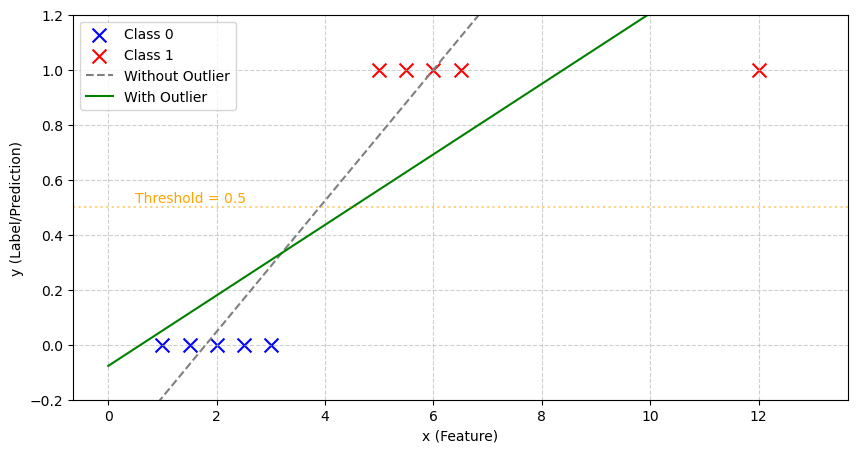

In [1]:
import matplotlib.pyplot as plt
import numpy as np
x0 = np.array([1, 1.5, 2, 2.5, 3])
y0 = np.zeros_like(x0)
x1 = np.array([5, 5.5, 6, 6.5])
y1 = np.ones_like(x1)
x_outlier = np.array([12])
y_outlier = np.array([1])
x = np.concatenate([x0, x1, x_outlier])
y = np.concatenate([y0, y1, y_outlier])
w1, b1 = np.polyfit(np.concatenate([x0, x1]), np.concatenate([y0, y1]), 1)
w2, b2 = np.polyfit(x, y, 1)
plt.figure(figsize=(10, 5))


plt.scatter(x0, y0, marker='x', color='blue', s=100, label='Class 0')
plt.scatter(x1, y1, marker='x', color='red', s=100, label='Class 1')
plt.scatter(x_outlier, y_outlier, marker='x', color='red', s=100) # 离群点


x_range = np.linspace(0, 13, 100)
plt.plot(x_range, w1 * x_range + b1, '--', color='gray', label='Without Outlier')
plt.plot(x_range, w2 * x_range + b2, '-', color='green', label='With Outlier')


plt.axhline(0.5, color='orange', linestyle=':', alpha=0.5)
plt.text(0.5, 0.52, 'Threshold = 0.5', color='orange')


plt.xlabel('x (Feature)')
plt.ylabel('y (Label/Prediction)')
plt.ylim(-0.2, 1.2)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

由于一个比较远的数据,这个函数被直接带偏了,所以我们介绍下一个算法
### Logistic regression 逻辑回归
我们认为,$h_\theta (x) \in [0,1]$,接下来就是大名鼎鼎的sigmod函数(logistic function),写作:
$$g(z) = \frac{1}{1 + e^{-z}}$$
本情境下,就是
$$h_\theta(x) = g(\theta^T x) = \frac{1}{1 + e^{-\theta^T x}}$$

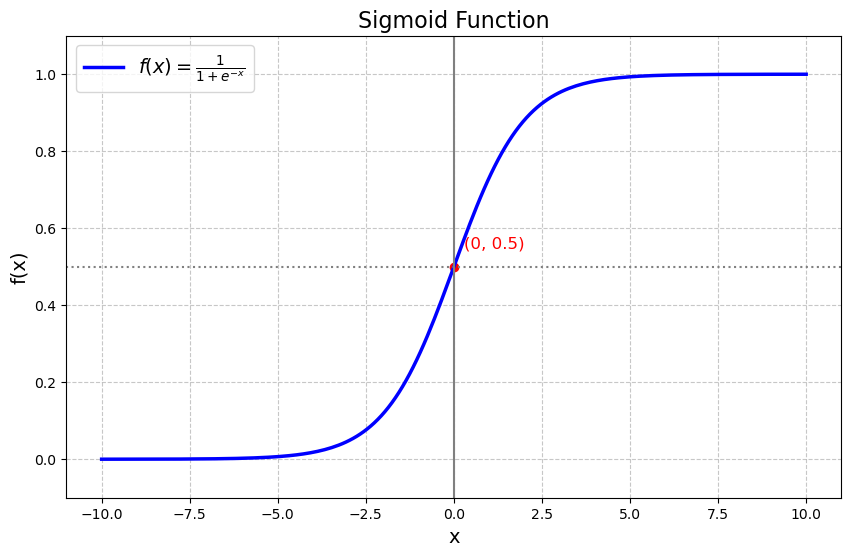

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 定义 Sigmoid 函数
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# 2. 生成 x 轴数据：从 -10 到 10，生成 200 个点
# 范围稍微宽一点（如 -10 到 10）可以更清楚地看到函数趋于 0 和 1 的过程
x = np.linspace(-10, 10, 200)

# 3. 计算对应的 y 值
y = sigmoid(x)

# 4. 绘图设置
plt.figure(figsize=(10, 6)) # 设置画布大小

# 画出 Sigmoid 曲线
plt.plot(x, y, label=r'$f(x) = \frac{1}{1 + e^{-x}}$', color='blue', linewidth=2.5)

# 5. 修饰图像
# 添加标题和坐标轴标签 (支持 LaTeX 公式)
plt.title('Sigmoid Function', fontsize=16)
plt.xlabel('x', fontsize=14)
plt.ylabel('f(x)', fontsize=14)

# 添加网格线，设为虚线
plt.grid(True, linestyle='--', alpha=0.7)

plt.axhline(y=0.5, color='gray', linestyle=':')  # 用 y 表示高度
plt.axvline(x=0, color='gray', linestyle='-')

# 设置 y 轴的显示范围，略大于 [0, 1]，留出一点空白，更美观
plt.ylim(-0.1, 1.1)

# 在特殊点 (0, 0.5) 处添加标记
plt.scatter([0], [0.5], color='red')
plt.text(0.3, 0.55, '(0, 0.5)', color='red', fontsize=12)

# 显示图例
plt.legend(fontsize=14)

# 6. 显示图像
plt.show()

我们假设有:$$P(y=1|x;\theta )=h_\theta(x)$$         
这意味着:$$P(y=0|x;\theta )=1-h_\theta(x)$$         
由于是一个二元问题,那就有:
$$P(y|x;\theta )=(1-h_\theta(x))^{1-y}h_\theta(x)^y$$
由此,有:
\begin{aligned}
L(\theta) &= p(\vec{y} | X; \theta) \\
&= \prod_{i=1}^{m} p(y^{(i)} | x^{(i)}; \theta) \\
&= \prod_{i=1}^{m} h_\theta(x^{(i)})^{y^{(i)}} (1 - h_\theta(x^{(i)}))^{1 - y^{(i)}}
\end{aligned}
同样的,取对数有:
\begin{aligned}
\ell(\theta) &= \log L(\theta) \\
&= \sum_{i=1}^{m} y^{(i)} \log h_\theta(x^{(i)}) + (1 - y^{(i)}) \log(1 - h_\theta(x^{(i)}))
\end{aligned}
为了能够预测,我们使用一种批量梯度上升法(batch gradient ascent):
$$\theta_j := \theta_j + \alpha \frac{\partial}{\partial \theta_j} \ell(\theta)$$

我们的目标是求对数似然函数 $\ell(\theta)$ 对参数 $\theta_j$ 的偏导数：$\frac{\partial}{\partial \theta_j} \ell(\theta)$

首先,我们介绍一个Sigmoid 函数的极其优美的求导性质,这是后续推导的基石

令 $g(z) = \frac{1}{1 + e^{-z}}$，对其求导：
$$
\begin{aligned}
g'(z) &= \frac{d}{dz} (1 + e^{-z})^{-1} \\
&= -(1 + e^{-z})^{-2} (-e^{-z}) \\
&= \frac{e^{-z}}{(1 + e^{-z})^2} \\
&= \left( \frac{1}{1 + e^{-z}} \right) \left( \frac{e^{-z}}{1 + e^{-z}} \right) \\
&= \left( \frac{1}{1 + e^{-z}} \right) \left( \frac{(1 + e^{-z}) - 1}{1 + e^{-z}} \right) \\
&= \left( \frac{1}{1 + e^{-z}} \right) \left( 1 - \frac{1}{1 + e^{-z}} \right) \\
&= g(z)(1 - g(z))
\end{aligned}
$$
**结论**：Sigmoid 函数的导数可以用它自己来表示，即 $g'(z) = g(z)(1 - g(z))$。

已知 $h_\theta(x) = g(\theta^T x)$，根据链式求导法则（令 $z = \theta^T x$）：
$$
\begin{aligned}
\frac{\partial}{\partial \theta_j} h_\theta(x) &= \frac{\partial}{\partial \theta_j} g(\theta^T x) \\
&= g'(\theta^T x) \cdot \frac{\partial}{\partial \theta_j} (\theta^T x) \\
&= g(\theta^T x)(1 - g(\theta^T x)) \cdot x_j \\
&= h_\theta(x)(1 - h_\theta(x))x_j
\end{aligned}
$$

为了简化书写，我们先只看单个样本 $(x, y)$ 的似然函数求导：
$$ \ell^{(i)}(\theta) = y \log h_\theta(x) + (1 - y) \log (1 - h_\theta(x)) $$

对其求 $\theta_j$ 的偏导：
$$
\begin{aligned}
\frac{\partial}{\partial \theta_j} \ell^{(i)}(\theta) &= y \frac{1}{h_\theta(x)} \frac{\partial}{\partial \theta_j}h_\theta(x) + (1 - y) \frac{1}{1 - h_\theta(x)} \left( - \frac{\partial}{\partial \theta_j}h_\theta(x) \right) \\
\end{aligned}
$$

将公因式 $\frac{\partial}{\partial \theta_j}h_\theta(x)$ 提取出来：
$$
\begin{aligned}
\frac{\partial}{\partial \theta_j} \ell^{(i)}(\theta) &= \left( \frac{y}{h_\theta(x)} - \frac{1 - y}{1 - h_\theta(x)} \right) \frac{\partial}{\partial \theta_j}h_\theta(x)
\end{aligned}
$$

将括号内通分化简：
$$
\begin{aligned}
\frac{\partial}{\partial \theta_j} \ell^{(i)}(\theta) &= \left( \frac{y(1 - h_\theta(x)) - (1 - y)h_\theta(x)}{h_\theta(x)(1 - h_\theta(x))} \right) \frac{\partial}{\partial \theta_j}h_\theta(x) \\
&= \left( \frac{y - y \cdot h_\theta(x) - h_\theta(x) + y \cdot h_\theta(x)}{h_\theta(x)(1 - h_\theta(x))} \right) \frac{\partial}{\partial \theta_j}h_\theta(x) \\
&= \left( \frac{y - h_\theta(x)}{h_\theta(x)(1 - h_\theta(x))} \right) \frac{\partial}{\partial \theta_j}h_\theta(x)
\end{aligned}
$$

此时，将我们在**第二步**中求得的 $\frac{\partial}{\partial \theta_j} h_\theta(x) = h_\theta(x)(1 - h_\theta(x))x_j$ 代入上式：

$$
\begin{aligned}
\frac{\partial}{\partial \theta_j} \ell^{(i)}(\theta) &= \left( \frac{y - h_\theta(x)}{h_\theta(x)(1 - h_\theta(x))} \right) \cdot h_\theta(x)(1 - h_\theta(x))x_j
\end{aligned}
$$

极其完美的消元发生了！分子分母的 $h_\theta(x)(1 - h_\theta(x))$ 被完全约掉：
$$
\frac{\partial}{\partial \theta_j} \ell^{(i)}(\theta) = (y - h_\theta(x))x_j
$$

加上所有 $m$ 个样本的求和符号 $\sum$，我们得到最终的偏导数：
$$
\frac{\partial}{\partial \theta_j} \ell(\theta) = \sum_{i=1}^m \left( y^{(i)} - h_\theta(x^{(i)}) \right) x_j^{(i)}
$$

所以，梯度上升的参数更新公式为（注意这里是极大似然，所以是加号 $+$）：
$$
\theta_j := \theta_j + \alpha \sum_{i=1}^m \left( y^{(i)} - h_\theta(x^{(i)}) \right) x_j^{(i)}
$$

<p style="color: #d93025; font-family: monospace; font-size: 16px; font-weight: bold;">
  ⚠️ 注意：上述所有的log指的是ln而不是以10为底的对数
</p>

不难注意到,这个和**线性回归（最小二乘法）的梯度下降公式**放在一起对比时：

*   **线性回归更新规则**：$\theta_j := \theta_j - \alpha \sum (h_\theta(x) - y) x_j$  （把负号放进去就是 $\theta_j + \alpha \sum (y - h_\theta(x)) x_j$）
*   **逻辑回归更新规则**：$\theta_j := \theta_j + \alpha \sum (y - h_\theta(x)) x_j$

这是巧合吗？绝对不是,区别在于压缩机”变了：
*   线性回归里：$h_\theta(x) = \theta^T x$
*   逻辑回归里：$h_\theta(x) = \frac{1}{1 + e^{-\theta^T x}}$

它证明了这两种算法在底层被称为**广义线性模型（GLM）**，它们归根结底是"同一类"模型




我看完之后再想全局最大值为什么一定存在呢?为什么不会是局部极值?为什么一定会有最大值?我问了ai,但是现在看不懂,暂存此处

<details>
  <summary>凭什么我们能那么自信地闭着眼睛用梯度上升？</summary>
  
一句话回答：**因为数学家通过证明发现，逻辑回归的对数似然函数 $\ell(\theta)$ 是一个完美的“凹函数”（Concave Function）！** （对应的，如果前面加个负号变成损失函数 $J(\theta)$，就是一个完美的“凸函数” Convex Function）。

这种函数就像一个倒扣过来的“平滑大碗”，它**永远只有一个碗底/碗顶**，没有任何其他坑坑洼洼的假山头。

作为助教，我直接带你深入数学底层，把这个证明过程“硬核”地推演一遍，并解答你关于“压根没有最大值”的极其深刻的直觉。

---
第一步：怎么证明它是“平滑大碗”（凹函数）？

在高数中，证明一个一元函数只有唯一极值的办法是：**求二阶导数**。
* 如果二阶导数恒小于 0（比如 $y = -x^2$），说明曲线永远在往下弯，必定只有一个全局最高点。

在机器学习（多元微积分）中，$\theta$ 是一个向量，所以二阶导数变成了一个矩阵，叫做 **海森矩阵（Hessian Matrix, 记作 $H$）**。
我们要证明：**对于逻辑回归，它的海森矩阵是“半负定”的（Negative Semi-Definite）**，这就等价于一元函数里的“二阶导数恒小于或等于0”。

极简推导过程（你可以记在笔记里）：

刚才我们已经算出了**一阶导数（梯度）**：
$$ \frac{\partial \ell}{\partial \theta_j} = \sum_{i=1}^m (y^{(i)} - h_\theta(x^{(i)})) x_j^{(i)} $$

现在，我们对这个一阶导数，再求一次导，算出关于 $\theta_k$ 的**二阶导数**：
（注意，$y^{(i)}$ 和 $x_j^{(i)}$ 都是常量，只有 $h_\theta(x^{(i)})$ 里面含有 $\theta$）

$$ \frac{\partial^2 \ell}{\partial \theta_j \partial \theta_k} = \sum_{i=1}^m - \frac{\partial}{\partial \theta_k} h_\theta(x^{(i)}) \cdot x_j^{(i)} $$

还记得我们推导过的 Sigmoid 导数吗？$\frac{\partial h_\theta(x)}{\partial \theta_k} = h_\theta(x)(1 - h_\theta(x)) x_k$。把它代进去：

$$ H_{jk} = - \sum_{i=1}^m \underbrace{h_\theta(x^{(i)})(1 - h_\theta(x^{(i)}))}_{\text{必然大于 0}} x_j^{(i)} x_k^{(i)} $$

**🔥 见证奇迹的时刻：**
看公式里的那一项 $h_\theta(x) (1 - h_\theta(x))$。
因为 $h_\theta(x)$ 是 Sigmoid 函数的输出，它的值域永远在 $(0, 1)$ 之间。
所以，一个 $0$ 到 $1$ 之间的数，乘以 $(1 - \text{它自己})$，**结果绝对是一个大于 0 的正数！**

如果把上面的式子写成极其优雅的矩阵形式：
$$ H = - X^T S X $$
（其中 $S$ 是一个对角线上全为正数的矩阵）。

在线性代数中，任何形如 $X^T S X$ （$S$ 为正对角阵）的矩阵必定是**半正定**的。前面加了一个负号，所以逻辑回归的海森矩阵 $H$ 永远是**半负定**的！

**数学结论：** 既然海森矩阵半负定，这就严谨地证明了 $\ell(\theta)$ 是一个绝对纯粹的凹函数（Concave）。**它绝对不存在任何局部最大值，你只要顺着梯度往上爬，到达的那个顶点，100% 就是全宇宙唯一的全局最高点！**

---

第二步：你直觉超神的一点 —— “或者压根没有最大值？”

如果你在推导完上面那段之后，依然觉得“压根没有最大值”是有可能的，那你真的具备了成为顶级算法工程师的直觉。

**你说对了！在一种极其特殊的情况下，逻辑回归的 $\ell(\theta)$ 真的找不到最大值点！**

这种情况叫做：**数据完美线性可分（Linearly Separable）**。

*   **直觉想象**：假设你的数据非常好区分，所有的良性肿瘤全在左边，所有的恶性肿瘤全在右边，中间有一道极其清晰的界限（可以画出无数条完美的直线把它们分开）。
*   **算法的贪婪**：MLE 的目标是让概率最大化（无限逼近 100%）。为了让模型对这些数据的预测概率从 $0.99$ 变成 $0.99999$，再变成 $0.99999999$…… 逻辑回归会做一件疯狂的事：
*   **它的参数 $\theta$ 的数值会无限膨胀，直接冲向正无穷或负无穷（$\infty$）！**

因为 Sigmoid 曲线只有在自变量无穷大的时候，才能真正摸到 $1.0$ 的天花板。
所以在这种情况下，梯度上升算法会永远跑下去，$\theta$ 会越来越大，似然函数永远在逼近最大值，却**压根永远达不到那个最大值**。

怎么解决这个致命问题？
既然 $\theta$ 想膨胀到无穷大，我们就必须在数学上“栓”住它。
这就是吴恩达老师在接下来几节课一定会重磅推出的概念：**正则化（Regularization）**。

通过在目标函数后面强行加一个“惩罚项”（比如 $\lambda \sum \theta_j^2$），只要 $\theta$ 敢膨胀，系统就狠狠地扣它的分。
加上正则化之后，函数就会从“可能没有最大值”的半凹函数，变成**严格凹函数（Strictly Concave）**，从而保证无论数据长什么样，都有一个唯一且有限的全局最优解。
  
</details>




### Newton's method牛顿法
刚刚我们使用梯度下降法解决分类问题,但是需要多次迭代,我们介绍牛顿法可以显著减少迭代次数,接下来是一个示意图,介绍了运作方法

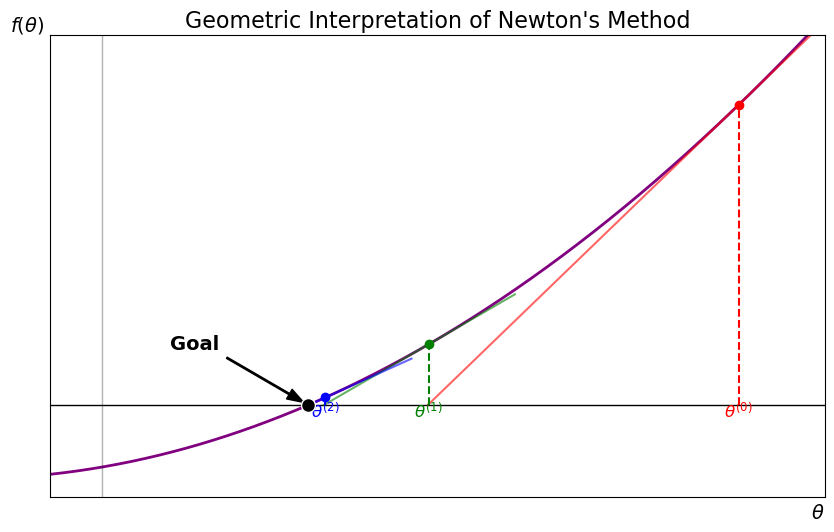

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 定义函数 f(x) 及其导数 f'(x)
# 这里选一个类似图中形状的二次函数：f(x) = 0.5*x^2 - 2
def f(x):
    return 0.5 * x**2 - 2

def df(x):
    return x

# 2. 准备绘图数据
x_range = np.linspace(0.5, 5, 400)
y_range = f(x_range)

# 3. 模拟牛顿法迭代步骤
theta_samples = [4.5, 2.7, 2.1]  # 手动选几个点模拟 theta(0), (1), (2)
colors = ['red', 'green', 'blue']

plt.figure(figsize=(10, 6))

# 画出 f(x) 曲线
plt.plot(x_range, y_range, color='purple', label='$f(\\theta)$', linewidth=2)
# 画出 x 轴
plt.axhline(0, color='black', linewidth=1)
# 画出 y 轴
plt.axvline(0.8, color='black', linewidth=1, alpha=0.3)

# 4. 循环绘制迭代过程
for i, t in enumerate(theta_samples):
    y_val = f(t)
    slope = df(t)
    
    # 画垂直虚线：从轴到曲线上的点
    plt.vlines(t, 0, y_val, colors=colors[i], linestyles='--')
    
    # 画切线：y - f(t) = f'(t)(x - t) -> y = f'(t)*(x - t) + f(t)
    # 计算切线与 x 轴的交点 (即下一个 theta)
    next_t = t - y_val / slope
    t_tangent = np.linspace(next_t, t + 0.5, 100)
    y_tangent = slope * (t_tangent - t) + y_val
    plt.plot(t_tangent, y_tangent, color=colors[i], alpha=0.6)
    
    # 标记点
    plt.scatter([t], [y_val], color=colors[i], zorder=5)
    plt.text(t, -0.3, f'$\\theta^{{({i})}}$', color=colors[i], 
             fontsize=12, ha='center')

# 5. 标注 "Goal" (零点)
goal_x = 2.0  # f(2)=0
plt.annotate('Goal', xy=(goal_x, 0), xytext=(1.2, 1.5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
             fontsize=14, fontweight='bold')
plt.scatter([goal_x], [0], color='black', s=100, edgecolors='white', zorder=6)

# 6. 图表装饰
plt.title("Geometric Interpretation of Newton's Method", fontsize=16)
plt.xlabel('$\\theta$', loc='right', fontsize=14)
plt.ylabel('$f(\\theta)$', loc='top', rotation=0, fontsize=14)
plt.grid(True, linestyle=':', alpha=0.5)
plt.xlim(0.5, 5)
plt.ylim(-2.5, 10)

# 隐藏坐标轴刻度，模仿手绘感
plt.xticks([])
plt.yticks([])

plt.show()

首先,我们记
$$ \theta^{(1)} := \theta^{(0)} - \Delta   $$
其中,定义增量为 $\Delta$

考察上图中$\theta^{(1)}$和$\theta^{(2)}$一段,这部分切线有
$$
f'(\theta^{(0)}) = \frac{f(\theta^{(0)})}{\Delta} \\
$$
移项得到
$$
\Delta = \frac{f(\theta^{(0)})}{f'(\theta^{(0)})}
$$
带入后得到每次的规律:
$$
 \theta^{(t+1)} := \theta^{(t)} - \frac{f(\theta^{(t)})}{f'(\theta^{(t)})} 
$$
这就是通用牛顿零点公式,接下来,我们令 $f$ 为似然函数 $\ell$ 的导数,就有
$$
\text{Let } f(\theta) = \ell'(\theta) 
$$
$$\theta^{(t+1)} := \theta^{(t)} - \frac{\ell'(\theta^{(t)})}{\ell''(\theta^{(t)})} $$

牛顿法还有一个二次收敛的特性(quadratic convergence)
大概意思是每迭代一次，有效数字的位数大约会翻一倍。对比来看,
- 线性收敛（如梯度下降）：如果当前误差是 $0.1$，下一步可能是 $0.09$，再下一步是 $0.081$。你需要走很多步才能增加一位小数的精度。
- 二次收敛（如牛顿法）：如果当前误差是 $10^{-2}$，下一步大约就是 $(10^{-2})^2 = 10^{-4}$，再下一步就是 $10^{-8}$，接着是 $10^{-16}$。这意味着，一旦你进入了目标值附近的“收敛区域”，牛顿法通常只需要 5 到 10 次迭代就能达到计算机浮点数的精度极限。

当$\theta$是向量时($\theta \in \mathbb{R}^{n+1}$)
$$\theta^{(t+1)}:=\theta^{(t)}-H^{-1} \nabla _\theta \ell $$

下面详细解释这个公式,我们将原先的一维和现在的对比:
| 一元标量| 多元向量 | 
| :--- | :--- | 
| $\theta$ | $\theta$ (向量 $\in \mathbb{R}^{n+1}$) | 
| $\ell'(\theta)$ (一阶导数) | $\nabla_\theta \ell$ (梯度向量) | 
| $\ell''(\theta)$ (二阶导数) | $H$ (Hessian 海森矩阵) | 
| 除法 $\frac{1}{\ell''(\theta)}$ | 矩阵求逆 $H^{-1}$ | 

把右边那一列组合起来，一元公式 $\theta := \theta - \frac{\ell'(\theta)}{\ell''(\theta)}$ 就完美变成了：

$$ \theta^{(t+1)} := \theta^{(t)} - H^{-1} \nabla_\theta \ell $$

至于什么是Hessian矩阵,定义为:
$$ H_{ij} = \frac{\partial^2 \ell}{\partial \theta_i \partial \theta_j} $$

对于有 $n$ 个维度的特征向量 $x$ （算上截距项是 $(n+1)$ 个），那么梯度 $\nabla_\theta \ell$ 是一个 $(n+1)$ 行 1 列的向量。
而 Hessian 矩阵 $H$ 就是一个 **$(n+1) \times (n+1)$ 的方阵**。

总结来看,newton法在低维度时比较好用,因为非常的快,但是因为每一次运算量非常的,当维度比较高的时候,对一个极大的Hessian矩阵求逆($O(n^3)$)是非常困难的,所以其适用范围一般是特征数较少的情况,此时梯度下降只要求导就好了

> 喜报喜报,Lecture1&2&3已经全部上完!
> ~~lecture4的印度哥们口音真重~~




### Perceptron 感知机
感知机算法其实就是相对于sigmod函数的另一种激活函数,如下:
$$
\begin{equation*}
g(z) = 
\begin{cases} 
1 & \text{if } z \geq 0 \\
0  & \text{if } z < 0 
\end{cases}
\end{equation*}
$$
同样的,就有
$$
h_\theta(x)=g(\theta^Tx)
$$
带入到公式:
$$\theta_j := \theta_j + \alpha \left( y^{(i)} - h_\theta(x^{(i)}) \right) x_j^{(i)}$$
观察发现,这个公式有"自愈能力",
重点就在这个括号里的误差项 $\mathbf{(y^{(i)} - h_\theta(x^{(i)}))}$：

*   **场景 A：算法预测对了**
    *   如果真实的 $y^{(i)}=1$，算法预测的 $h_\theta(x) \approx 1$。
    *   误差项 $\approx 1 - 1 = 0$。
    *   **结果**：公式右边那一项几乎为 0，$\theta$ **几乎不更新**。这很合理：既然预测准了，就维持现状。

*   **场景 B：算法预测错了**
    *   **情况 1：漏报（应该是1，但预测成0）**
        *   真实 $y^{(i)}=1$，预测 $h_\theta(x) \approx 0$。
        *   误差项 $\approx 1 - 0 = +1$。
        *   **结果**：$\theta$ 会加上一个正数。这会把预测结果往“1”的方向推。
    *   **情况 2：误报（应该是0，但预测成1）**
        *   真实 $y^{(i)}=0$，预测 $h_\theta(x) \approx 1$。
        *   误差项 $\approx 0 - 1 = -1$。
        *   **结果**：$\theta$ 会减去一个正数。这会把预测结果往“0”的方向拉。

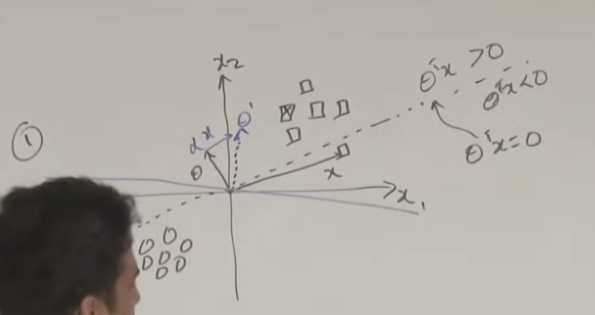

而如图例子可以发现:
1.  **$\theta$ 是法向量**：
    在数学上，方程 $\theta^T x = 0$ 定义了一个过原点的超平面。**向量 $\theta$ 永远垂直于这个平面**。在图中，$\theta$ 指向的方向通常被定义为“正例（Class 1）”的方向。

2.  **点积决定类别**：
    *   如果数据点 $x$ 与 $\theta$ 的夹角小于 90 度，那么 $\theta^T x > 0$，模型预测 $y=1$（图中右上角区域）。
    *   如果数据点 $x$ 与 $\theta$ 的夹角大于 90 度，那么 $\theta^T x < 0$，模型预测 $y=0$（图中左下角区域）。

3.  **更新的本质是“旋转”**：
   
    *   图中那些虚线箭头展示了：如果算法预测错了（比如一个 $y=1$ 的点掉到了 $y=0$ 的区域），更新公式 $\theta := \theta + \alpha x$ 实际上是在**把向量 $\theta$ 往该点 $x$ 的方向拉**。
    而最简单的旋转方式就是矢量加法,新矢量一定在两矢量中,这也就是"旋转"或者"拉"的意思
    *   随着 $\theta$ 的旋转，垂直于它的决策边界也会跟着摆动，直到把那个点划入正确的区域。



> Anand讲完之后有人问为什么现在用的很少了,他是这么回答的:

> "um, it- it does not have a probabilistic interpretation of what's- what's happening.
嗯，它——它对正在发生的事情没有概率性的解释。"

> 如何理解这句话呢?我在查找总结之后得到的是:

> 1.缺乏可判断性:我们永远不知道这到底是怎么样的数值,面对损失函数,我们可以知道还差多少,是否是在往误差更小的情况计算,但是面对这个算法,我们只能被动的被新的数据像左边/右边牵着走一点,如果你现在错了 10 个点，移动一下后依然错 10 个点，感知机根本不知道自己是离正确答案更近了还是更远了

> 2.这是更致命的,如果数据极为杂乱,甚至只要是交叉的,那就面临缺少线性可分（Linearly Separable）,也就是说,根本没有一条直线可以做到分开,这样感知机只会让线在平面上盲目的转动

## Generalized Linear Models (GLM) 广义线性模型
### exponential families指数分布族
这是一类概率分布,pdf(probility density function)可以被写作:
$$
p(y; \eta) = b(y) \exp(\eta^T T(y) - a(\eta))   \tag{1} 
$$


由于这是监督学习,上述式子是为了在$y$已知的情况下得到$\eta$,所以
- $y$:数据(data)
- $\eta$:自然参数（Natural parameter）
- $T(y)$:充分统计量（Sufficient statistic）(无需理解,$T(y)$在此就是$y$)
- $a(\eta)$:对数配分函数（Log partition function），用于确保概率积分为 1
- $b(y)$:基础测度（Base measure）



我们以**Bernoulli分布**为例
首先定义概率质量函数，其中 $\phi$ 是事件发生的概率：
$$p(y; \phi) = \phi^y (1 - \phi)^{(1-y)}$$
通过取对数再取指数（$e^{\log x} = x$）的方法进行变换：
$$\begin{aligned} p(y; \phi) &= \exp\left( \log\left( \phi^y (1 - \phi)^{(1-y)} \right) \right) \\ &= \exp\left( y \log \phi + (1-y) \log(1-\phi) \right) \\ &= \exp\left( y \log \phi + \log(1-\phi) - y \log(1-\phi) \right) \\ &= \exp\left( \left( \log \frac{\phi}{1-\phi} \right) y + \log(1-\phi) \right) \end{aligned}$$
对照指数族分布的标准公式 $p(y; \eta) = b(y) \exp(\eta^T T(y) - a(\eta))$，可以得出图中标注的各个分量：
$$\underbrace{1}_{b(y)} \exp \left[ \underbrace{\log\left(\frac{\phi}{1-\phi}\right)}_{\eta} \underbrace{y}_{T(y)} + \underbrace{\log(1-\phi)}_{a(\eta)} \right]$$
**对应关系：**
* **基础测度 (Base measure):** $b(y) = 1$
* **自然参数 (Natural parameter):** $\eta = \log\left(\frac{\phi}{1-\phi}\right)$ （即 log-odds 或 logit 函数）
* **充分统计量 (Sufficient statistic):** $T(y) = y$
* **对数配分函数 (Log partition function):** $a(\eta)$ （此处标记为 $-\log(1-\phi)$，通常在标准形式中会写成减去一个关于 $\eta$ 的函数）

下面是以Gaussian分布为例:
假设方差 $\sigma^2 = 1$，则其概率密度函数为：
$$p(y; \mu) = \frac{1}{\sqrt{2\pi}} \exp\left( -\frac{(y-\mu)^2}{2} \right)$$
通过展开指数项 $(y-\mu)^2 = y^2 - 2\mu y + \mu^2$，可以将其变形为：
$$p(y; \mu) = \underbrace{\frac{1}{\sqrt{2\pi}} e^{-\frac{y^2}{2}}}_{b(y)} \exp(\underbrace{\mu}_{\eta} \underbrace{y}_{T(y)} - \underbrace{\frac{1}{2}\mu^2}_{a(\eta)})$$
* **基本测度 (Base measure):**
    $$b(y) = \frac{1}{\sqrt{2\pi}} \exp\left( -\frac{y^2}{2} \right)$$
* **充分统计量 (Sufficient statistic):**
    $$T(y) = y$$
* **自然参数 (Natural parameter):**
    $$\eta = \mu$$
* **对数配分函数 (Log partition function):**
    $$a(\eta) = \frac{\mu^2}{2} = \frac{\eta^2}{2}$$


之所以使用指数族是因为其一些良好的性质,比如
- 在进行最大似然估计中,关于$\eta$的MLE是凹的,而NLE(负对数似然)是凸的
-  对 $a(\eta)$ 求一阶导数，就能得到均值（期望）；求二阶导数，就能得到方差



下面先证明第二点:
将式子(1)移项后处理得到:
$$ \int b(y) \exp(\eta y) dy = \exp(a(\eta)) \tag{2} $$
先证明得到期望:

现在，我们在(2)的左右两边，同时对 **$\eta$ 求导**：
*   **左边求导**：$\frac{\partial}{\partial \eta} \int b(y) \exp(\eta y) dy = \int y \cdot b(y) \exp(\eta y) dy$
*   **右边求导**（链式法则）：$\frac{\partial}{\partial \eta} \exp(a(\eta)) = a'(\eta) \exp(a(\eta))$

所以我们得到：
$$ \int y \cdot b(y) \exp(\eta y) dy = a'(\eta) \exp(a(\eta)) $$
把 $\exp(a(\eta))$ 除回左边放进积分里：
$$ \int y \cdot \underbrace{b(y) \exp(\eta y - a(\eta))}_{\text{这正好是 } p(y;\eta)} dy = a'(\eta) $$
化简之后：
$$ \int y \cdot p(y; \eta) dy = a'(\eta) $$
**等式左边是什么？定义上，它就是期望 $E[y]$！**
$$ E[y; \eta] = \frac{\partial}{\partial \eta} a(\eta) $$

接着证明方差式子:

我们对刚才得到的等式 $\int y \cdot b(y) \exp(\eta y) dy = a'(\eta) \exp(a(\eta))$ **再求一次导**：
*   **左边求导**：$\int y^2 \cdot b(y) \exp(\eta y) dy$
*   **右边求导**（乘积法则）：$a''(\eta) \exp(a(\eta)) + (a'(\eta))^2 \exp(a(\eta))$

同样，把 $\exp(a(\eta))$ 除回左边：
$$ \int y^2 \cdot p(y; \eta) dy = a''(\eta) + (a'(\eta))^2 $$
等式左边就是 $E[y^2]$。而刚才在 (b) 中我们证明了 $a'(\eta) = E[y]$。代入进去：
$$ E[y^2] = a''(\eta) + (E[y])^2 $$
移项：
$$ a''(\eta) = E[y^2] - (E[y])^2 $$
期望的平方差等于方差 $\text{Var}(y)$！
$$ \text{Var}[y; \eta] = \frac{\partial^2}{\partial \eta^2} a(\eta) $$

非常的自然且elegant

至于(1) 的推导则直接来源于 (3)！
1. 我们刚才证明了 $\frac{\partial^2}{\partial \eta^2} a(\eta) = \text{Var}[y]$。
2. 众所周知，**任何变量的方差永远是非负的（$\text{Var} \ge 0$）**。
3. 这就意味着，$a(\eta)$ 的二阶导数永远大于等于 0！所以在数学上，$a(\eta)$ 绝对是一个**凸函数（Convex）**。
4. 当我们写出对数似然函数 $\ell(\eta) = \log p = \eta y - a(\eta) + \log b(y)$ 时，它包含了一个 $-a(\eta)$。
5. 因为 $a(\eta)$ 是凸的，前面加个负号，**$\ell(\eta)$ 就一定是一个绝对的凹函数（Concave，倒扣的碗）**！

补充一点,对于比如多元高斯分布,$\eta$会是一个向量,而(3)中的期望会是Hessian矩阵

最后做出一些总结:
- 实际数据(real data) 使用高斯(Gaussian)
- 二进制数据(binary) 使用伯努利(Bernoulli)
- 计数数据(count,非负整数) 使用泊松(Poission)
- 正实数数据(体积/某个事件发生的时间/预测类/...) 使用$\Gamma$分布或者指数分布(exponential) 
- 基于概率分布的概率分布(?~~不会喵~~) 比如$\beta$,狄利克雷分布(Dirichlet)(贝叶斯机器学习/贝叶斯统计学)

### GLM



 我们先做出一些假设:
- $y \mid x ; \theta \sim \text{Exponential Family}(\eta)$
- $\eta = \theta^T x$
- Test time: Output $E[y \mid x ; \theta] \Rightarrow h_\theta(x) = E[y \mid x ; \theta]$


第一个假设意思是给定特征$x$和参数$\theta$我们要预测的真实目标$y$(比如房价、点赞数、是猫是狗),服从某个$\eta$控制的“指数分布族”,这对应了上一个结尾的总结,我们通过选取指数族分布来确立了我们要用什么统计学规律来描述世界

第二个假设指数分布族的“核心控制旋钮” $\eta$(自然参数)，恰好等于特征$x$与权重$\theta$的线性组合（点乘）,这也是为什么叫广义**线性**模型,其假定了我们算出来所有维度都是一条直线方程,

第三个点意思是在输出阶段，当别人给你一个新的$x$让你预测结果时，你的模型应该输出这个分布的数学期望,也就是说.$h_\theta (x)$应该输出数学期望,这与之前的线性回归和逻辑回归一摸一样!分别是高斯分布和伯努利分布的期望!与其说一模一样,更可靠的说法应该是就是由此推出

> 我最开始无法理解第三个假设,期望看起来似乎很自然,但是有没有原因呢?为什么取这个作为假设?我在思考后总结如下:

> 在进行ML时,模型内部其实算出了一个完整的概率分布,但是分布在现实中不能解决问题,于是我们就取最能代表这个分布或者说在这个分布中的最优解

接下来是我针对现有知识的一些思考,首先,我觉得最神奇的是指数族分布的式子是咋来的?为什么将已有的数值$\eta$和我想要的分布套进去就可以直接得到符合要求的分布?ai给的答案是"它不是被“发明”出来的，它是被数学家“提炼”出来的",现在我的数学基础不是很够,关于这个问题有缘再说

第二个问题,从已有的GLM算法我们可以发现,这个预测的结果准不准,完全取决于$\theta$(相关性)和筛选机器(分布)的选择,真正决定输出的就这两个,这也与机器学习架构设计的核心心法：【模型 = 数据特征表达 + 假设空间】不谋而合

第三个发现,$\eta$在这个算法里起到了至关重要的作用,和事实的训练交互完全取决于$\eta$,也就是我们将所有的信息压缩为了一个像"指标"一样的概念,由于数据和结构是相关的($\eta$正负决定了正相关还是负相关),所以这个数的数值就直接导致了和结果的关系,就像买房子,在对多个数据,如面积、地段、风水等进行综合评判后,你会直接得到一个"印象分",这决定了买与不买

最后一个发现指出了现在的线性模型一个问题,对于两个不同的情况,有可能由于加减凑巧得到了两个一样的$\eta$,这样不同的情况可能得到相似的输出,这也就是互补,比如一个人更帅一点,一个人更有礼貌一点,印象分可能是相似的,但是对于一些问题,比如必须要找到一个又帅又有钱的,这种无法互补的情况将在该模型下彻底完蛋

综上,我们形成了一个对整个线性模型的印象,我们再从训练到输出复盘一下:


输入阶段:
在已经训练好的模型中,我们给出特征$x$,这样就可以获得$\eta$,获得$\eta$后结合之前的
$$\text{Output:}\quad E[y \mid x ; \theta] \Rightarrow h_\theta(x) = E[y \mid x ; \theta]$$
我们就获得了结果

训练阶段:我们手上有之前的历史数据,现在需要获得$\theta$
通过
 $$ \nabla_\theta \ell = \sum_{i=1}^m (y^{(i)} - h_\theta(x^{(i)})) \cdot x^{(i)} $$
 等价于:
 $$\nabla_\theta \ell = X^T (Y - H)$$
 我们获得了(以梯度上升为例)更新$\theta$的公式:
 $$ \theta := \theta + \alpha \cdot \nabla_\theta \ell $$
 重复上述变化,当 $\theta$ 几乎不再变化（收敛），训练正式结束

总结而言,就是:
$$ \text{参数 } \theta \xrightarrow{\text{设计选择 } \theta^T x} \text{纯数学数字 } \eta \xrightarrow[\text{响应函数 } g]{\text{链接函数 } g^{-1}} \text{人类看得懂的期望 } \mu $$

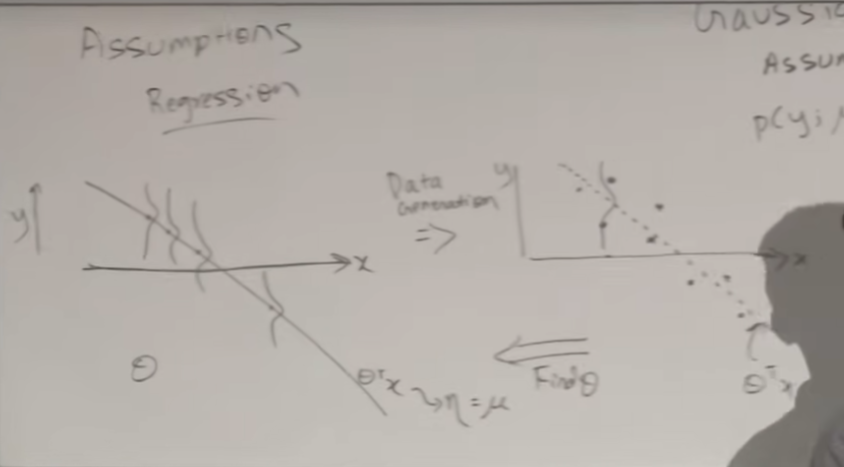
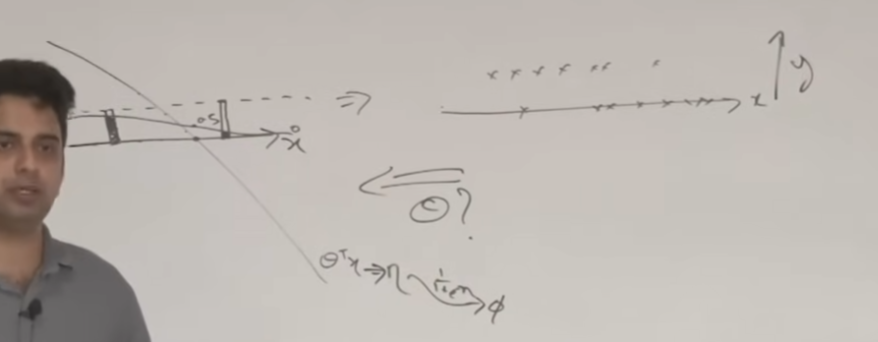

如上两幅图更清晰的解释了在GLM中线性回归和逻辑回归:
请仔细看图中间那两个巨大的箭头：**`Data Generation =>` (数据生成)** 和 **`<= Find \theta` (寻找参数)**。
**1. 左半边：上帝视角 (`Data Generation =>`)
*   **那条斜线**：这是上帝心里的一把尺子，代表了绝对真理 $\theta^T x$。
*   **线上的波浪**：这是一些**竖起来的高斯钟形曲线**。
*   **理解**：上帝在创造一个房价数据时，先看特征 $x$ 对应到直线上的高度（$\eta = \mu = \theta^T x$），把这里作为期望(曲线中心)。然后，上帝在这个期望里**随机抓阄**，抓到一个具体的点作为最终真实的房价 $y$。因为沙堆中心高，所以抓出来的房价大概率在直线附近，但也可能偏离（噪声）。

**2. 右半边：凡人视角的“机器学习训练” (`<= Find \theta`)**
*   **散落的点**：我们凡人（或者计算机）是看不到上帝那条直线的！我们只能收集到右边这些散落的星星点点（真实的历史数据集）。
*   **那条虚线**：我们的任务，就是在这堆散点中，反向推导出一条虚线，试图完美重合上帝心里的那条实线。
*   **怎么找？** 用极大似然估计（MLE）去转动虚线，找到那个能让这些散点出现概率最大的 $\theta$。


### softmax函数( multiclass classification 多分类问题) 
首先在面对多分类问题时,我们先给出一些名词定义:
- $K$ - # classes :表示一共有$K$种情况,即$K$类
- $x^{(i)} \in \mathbb{R}^n$:不变,表示第 $i$ 个样本是一个 $n$ 维的特征向量
- Label $y \in \{0, 1\}^K$:这是最大的变化!在之前的逻辑回归里,标签 $y$ 只是一个单一的数字（0 或 1）,但现在,$y$ 变成了一个长度为 $K$ 的向量,里面只有 0 和 1。

比如:`[0, 0, 1, 0]`,这是一个具体的例子(假设 $K=4$),它代表这个样本属于第 3 个类别,也就是我们使用1来表示属于所属的类别

我们将这种一个标签对应一个类别的情况称为`"One-hot label"`,这意味着一个样本只能属于一个类别
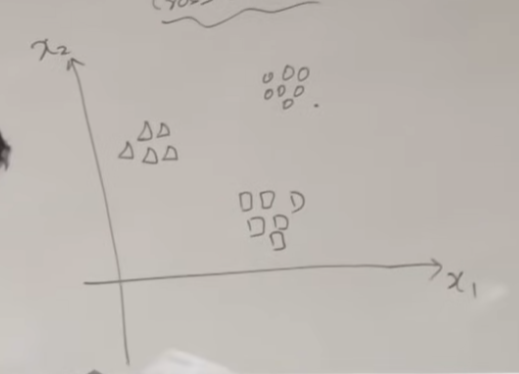

比如上图,这就意味着一共有三个类别,`[0,0,1]`可能就指的是圆形,类似于二元分类,我们需要找到分割平面的直线,但是由于不止一种元素,这就意味着不止一条直线:
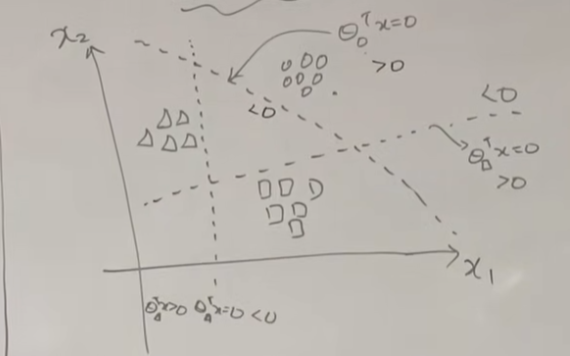

比如我们取点靠近正方形,那么在经这几个直线(转置)计算就可以得到左上角的柱状图,再将其取指数,就可以得到正实数,最后正则化(normalize),就得到了高度之和为1的柱状图,此时就可以表示一个分布,我们记这个分布为$\hat{p}(y)$,同时给出答案,比如此处其实是一个三角形,记分布为$p(y)$,这个分布是一个只有三角形横坐标为1,其余均为0的分布;那么我们就希望将$\hat{p}(y)$和$p(y)$距离减小

首先由上述操作可以得到:
$$ \hat{P}(y=k \mid x) = \frac{\exp(\theta_k^T x)}{\sum_{j=1}^K \exp(\theta_j^T x)} $$
这个就是softmax函数

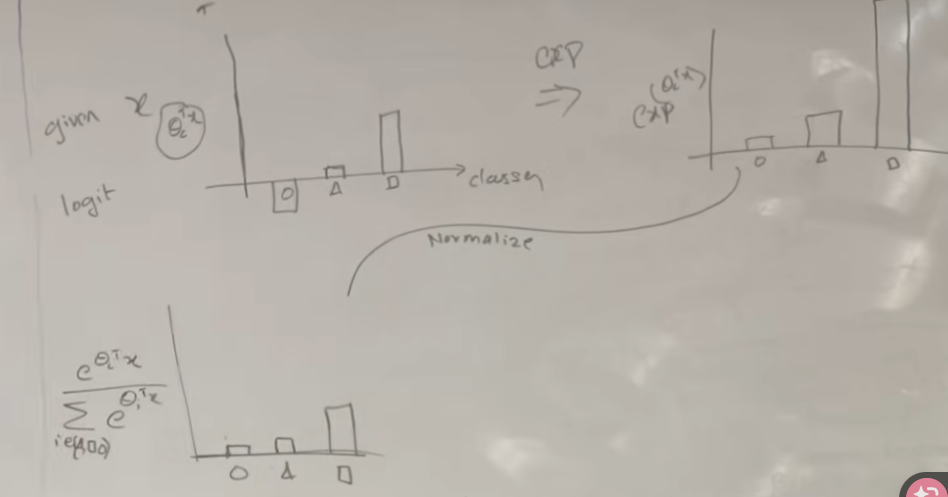

将分布距离减小的属于就是最小化两个分布之间的交叉熵(minimize the cross entropy between the two distributions),我们接下来介绍**cross entropy minimization(交叉熵最小化)**

先给出完整的交叉损失熵函数(Cross-Entropy Loss):
$$ \text{CrossEnt}(P, \hat{P}) = - \sum_{y \in \{1, 2, \dots, K\}} P(y) \log \hat{P}(y) $$
容易发现,由于$P(y)$是一个one-hot标签,这就导致乘出来只剩下正确的一项,也就是说,这个公式只盯着那个正确的类别预测概率,也就是对其求负对数,这使得惩罚机制非常完善:
*   假设模型预测“鸟”的概率是 **0.99**:Loss = $-\log(0.99) \approx 0.01$ (几乎没有惩罚，非常小)
*   假设模型预测“鸟”的概率是 **0.01**:Loss = $-\log(0.01) \approx 4.6$ (惩罚极其巨大！如果预测为0,惩罚趋于无穷大)


> lecture4已经全部结束了,接下来是一些关于交叉熵和softmax与GLM的关系的个人笔记:
1. 从数学角度上,什么是交叉熵?
**1. 什么是“熵（Entropy）”？**
在物理学和信息论里，熵代表**混乱程度**或**不确定性**。
比如一枚硬币，两面都是花，你抛它的结果是 100% 确定的，它的熵就是 0。
如果是一枚公平的硬币，抛它的结果极度不确定，它的熵就最大。

**2. 什么是“交叉（Cross）”？**
“交叉”意味着有两个不同的事物在发生碰撞。在这里，这两个事物是：
*   **真实分布 $P$**：比如真实世界里，这张图片 100% 是一只猫 `[1, 0, 0]`。
*   **你的预测分布 $Q$ (也就是 $\hat{P}$)**：比如你的模型猜它是猫的概率是 70%，狗是 20%，鸟是 10% `[0.7, 0.2, 0.1]`。

**3. 数学本质揭秘：**
在信息论的严谨公式里，交叉熵其实由两部分相加组成：
$$ \text{CrossEntropy}(P, Q) = \text{熵}(P) + \text{KL散度}(P || Q) $$
*   **$\text{熵}(P)$**：真实世界的客观混乱度（不可消除的底线误差）。对于 One-hot 标签（100%确定的猫），这部分为 0。
*   **$\text{KL散度}$ (相对熵)**：这就是大名鼎鼎的“距离测度”。它衡量的是你的预测 $Q$ 偏离真实 $P$ 有多远。

**结论**：因为真实数据的熵是不变的，所以**最小化交叉熵，在数学上等价于“最小化你的预测分布和真实分布之间的距离”！**


接下来给出关于softmax回归的推导:

**第一步：明确损失函数与链式法则**
单样本的交叉熵损失函数（Cross-Entropy Loss）为：
$$ L = - \sum_{k=1}^K y_k \log(\hat{y}_k) $$

我们要对属于第 $c$ 类的权重向量 $\theta_c$ 求导。根据微积分链式法则，我们分两步走：先求 $L$ 对线性得分 $z_c$ 的偏导，再求 $z_c$ 对 $\theta_c$ 的偏导。
$$ \frac{\partial L}{\partial \theta_c} = \frac{\partial L}{\partial z_c} \cdot \frac{\partial z_c}{\partial \theta_c} $$

**第二步：求 Softmax 函数自身的导数 (The Softmax Derivative)**
这是整个推导中最难、也最精妙的一步。我们要看某个类别的得分 $z_c$ 发生变化时，各个概率 $\hat{y}_k$ 会怎么变。这分为两种情况：

*情况 1：当 $k = c$ 时（对自身求导）*
$$
\begin{aligned}
\frac{\partial \hat{y}_c}{\partial z_c} &= \frac{\partial}{\partial z_c} \left( \frac{e^{z_c}}{\sum_{j=1}^K e^{z_j}} \right) \\
&= \frac{e^{z_c} \left(\sum_{j=1}^K e^{z_j}\right) - e^{z_c} \cdot e^{z_c}}{\left(\sum_{j=1}^K e^{z_j}\right)^2} \quad \text{(根据商的求导法则)} \\
&= \frac{e^{z_c}}{\sum_{j=1}^K e^{z_j}} - \left(\frac{e^{z_c}}{\sum_{j=1}^K e^{z_j}}\right)^2 \\
&= \hat{y}_c - \hat{y}_c^2 \\
&= \hat{y}_c (1 - \hat{y}_c)
\end{aligned}
$$

*情况 2：当 $k \neq c$ 时（对其他类别求导）*
$$
\begin{aligned}
\frac{\partial \hat{y}_k}{\partial z_c} &= \frac{\partial}{\partial z_c} \left( \frac{e^{z_k}}{\sum_{j=1}^K e^{z_j}} \right) \\
&= \frac{0 \cdot \left(\sum_{j=1}^K e^{z_j}\right) - e^{z_k} \cdot e^{z_c}}{\left(\sum_{j=1}^K e^{z_j}\right)^2} \\
&= - \frac{e^{z_k}}{\sum_{j=1}^K e^{z_j}} \cdot \frac{e^{z_c}}{\sum_{j=1}^K e^{z_j}} \\
&= - \hat{y}_k \hat{y}_c
\end{aligned}
$$

**第三步：求交叉熵对线性得分 $z_c$ 的偏导 (魔法发生的时刻)**
现在，我们对交叉熵公式求 $z_c$ 的导数：
$$ \frac{\partial L}{\partial z_c} = - \sum_{k=1}^K y_k \frac{\partial}{\partial z_c} \log(\hat{y}_k) = - \sum_{k=1}^K y_k \frac{1}{\hat{y}_k} \frac{\partial \hat{y}_k}{\partial z_c} $$

由于求导分为 $k=c$ 和 $k \neq c$ 两种情况，我们把求和公式拆开：
$$ \frac{\partial L}{\partial z_c} = - \left[ y_c \frac{1}{\hat{y}_c} \frac{\partial \hat{y}_c}{\partial z_c} + \sum_{k \neq c} y_k \frac{1}{\hat{y}_k} \frac{\partial \hat{y}_k}{\partial z_c} \right] $$

将我们在第二步中求得的导数代入：
$$
\begin{aligned}
\frac{\partial L}{\partial z_c} &= - \left[ y_c \frac{1}{\hat{y}_c} \big(\hat{y}_c (1 - \hat{y}_c)\big) + \sum_{k \neq c} y_k \frac{1}{\hat{y}_k} \big(- \hat{y}_k \hat{y}_c\big) \right] \\
&= - \left[ y_c (1 - \hat{y}_c) - \sum_{k \neq c} y_k \hat{y}_c \right] \\
&= - \left[ y_c - y_c \hat{y}_c - \hat{y}_c \sum_{k \neq c} y_k \right]
\end{aligned}
$$

提取公因式 $\hat{y}_c$：
$$ \frac{\partial L}{\partial z_c} = - \left[ y_c - \hat{y}_c \left( y_c + \sum_{k \neq c} y_k \right) \right] $$

**注意**,
括号里的 $y_c + \sum_{k \neq c} y_k$，其实就是把所有的真实标签 $y_k$ 加起来！因为 $y$ 是 One-hot 编码，所有概率加起来必然等于 1：即 $\sum_{k=1}^K y_k = 1$。
所以，式子瞬间崩塌化简为：
$$ \frac{\partial L}{\partial z_c} = -[ y_c - \hat{y}_c \cdot 1 ] = \hat{y}_c - y_c $$

**第四步：得出最终梯度**
最后，由于 $z_c = \theta_c^T x$，所以 $\frac{\partial z_c}{\partial \theta_c} = x$。
套用第一步的链式法则：
$$ \frac{\partial L}{\partial \theta_c} = \frac{\partial L}{\partial z_c} \cdot \frac{\partial z_c}{\partial \theta_c} = (\hat{y}_c - y_c) x $$

*（注：如果极大似然估计的梯度上升，则是最大化对数似然，结果为 $(y_c - \hat{y}_c) x$。两者只差一个符号，本质完全一致！）*

以上这个推导也是为了引出接下来的总结,回顾可以发现,之前的所有算法全是以GLM为基础的,本质是没有区别的,全是指数分布族在不同物理场景下的“换壳”产物。这就意味着,掌握了 GLM,就学会了这所有的算法

同时由GLM的特征会发现,不管中间的公式多恶心（自然底数 $e$、商的导数法则、交叉熵的 $\log$）,只要遵循 GLM 的假设,最终算出来的参数更新梯度永远会完美抵消，坍缩成极其简单的一行：
**$$\text{修改步长 (Gradient)} = \text{你的预测错得多离谱 } (\hat{y} - y) \times \text{当前特征的大小 } x$$**
也就是公式:
$$X^T(\hat{y} - y)$$
这是指数族对数配分函数 $a'(\eta) = E[y]$ 带来的数学必然。

同时这也说明了概率论是机器学习的“灵魂”
没有概率解释的算法（如感知机 Perceptron）像个莽夫，只能给出非黑即白的硬切分，遇到不完美的数据就会永远震荡。引入了概率论，算法就拥有了“不确定性的量化（输出 0.8的置信度）”，并且为我们使用**极大似然估计（MLE）**提供了合法的数学依据。

由此可以给出对于可以使用GLM的问题的套路:

*   **输入端 (Input)**：收集到的高维特征矩阵 $X$ 和真实的标签 $Y$。
*   **第 1 步：线性压缩机 ($\eta = \theta^T x$)**
    *   **作用**：把成百上千个特征 $x_i$，通过权重 $\theta$ 压缩成数字 $\eta$。它只有大小，没有物理约束。
*   **第 2 步：指数族翻译器 / 激活函数 ($h_\theta(x) = g(\eta)$)**
    *   **作用**：把无意义的 $\eta$，强制转换成符合现实规律的**期望值**。
    *   *连续数值* $\rightarrow$ 选高斯分布 $\rightarrow$ 恒等翻译（直接输出 $\eta$） $\rightarrow$ **线性回归**
    *   *二分类 (0/1)* $\rightarrow$ 选伯努利分布 $\rightarrow$ Sigmoid 翻译（压到 $0\sim1$） $\rightarrow$ **逻辑回归**
    *   *多分类 (One-hot)* $\rightarrow$ 选多项式分布 $\rightarrow$ Softmax 翻译（概率和为 1） $\rightarrow$ **Softmax 回归**
*   **第 3 步：损失函数 ($Loss$)**
    *   **作用**：用极大似然估计（MLE）衡量“预测值”和“真实值”的差距。
    *   高斯对应 **均方误差 (MSE)**；多分类对应 **交叉熵 (Cross-Entropy)**。
*   **回传与更新 (Backward Update)**
    *   求导算出梯度 $\nabla \ell = X^T(\hat{Y} - Y)$。
    *   用梯度下降或 牛顿法（算 Hessian 矩阵，一步到位）更新 $\theta$。


由于我还没有实战,这是一些**ai给出**的实战注意事项:
实际操作中,按以下思路执行：
1.  **审视目标（看 $y$ 选择激活函数）**：
    先看标签 $y$ 是什么类型。是实数？选线性回归。是 0 和 1？选逻辑回归。是一组 One-hot 向量？选 Softmax。这决定了你的损失函数和激活函数。
2.  **处理数据特征（维度对齐）**：
    *   永远记得给特征矩阵 $X$ 手动加一列全为 $1$ 的列，这是为了吸收**截距（Intercept $\theta_0$）**。
    *   确保 $X$ 的维度是 $(m, n+1)$，$Y$ 的维度是 $(m, 1)$。
3.  **使用`numpy`以矩阵思维处理数据**：
    *   写推导用求和符号 $\sum$，写代码全换成矩阵乘法 `@` 和转置 `.T`。
    *   核心预测代码：`H = sigmoid(X @ theta)`
    *   核心梯度代码：`grad = X.T @ (H - Y) / m`
4.  **调试与防御性编程**：
    *   打印维度：经常 `print(X.shape, theta.shape)`，维度不对是 90% 的 Bug 来源。
    *   如果在用**牛顿法**，打印海森矩阵 $H$ 的维度，确保它是 $(n+1) \times (n+1)$ 的方阵，然后再求逆 `np.linalg.inv(H)`。


这是一些之前遇到的坑,这里重新提一下(ai整理):
1.  **数学符号的潜规则**：
    *   公式里出现的 $\log$，永远是**以 $e$ 为底的自然对数 $\ln$**，否则没法完美求导。
    *   $\theta$ 是我们要找的真理（凡人视角的常数），所以吴恩达喜欢写成 $P(y|x ; \theta)$，分号代表它不是随机变量。
2.  **牛顿法的致命弱点**：
    *   虽然它有“二次收敛”的神奇速度（走 5 步顶梯度下降 500 步），但它需要求 $H^{-1}$。当特征数 $n$ 极大（如神经网络）时，求逆矩阵会让计算机内存和 CPU 直接爆炸。**小数据用牛顿，大数据用梯度。**
3.  **Pandas 与 NumPy 的边界**：
    *   在极其底层的数学算法手写复现中（如 CS229 作业），尽量用纯 NumPy Array 参与矩阵乘法。Pandas 的 Index 极易导致矩阵维度莫名其妙不对齐。
4.  **统计工具箱（卡西欧计算器等）的使用**：
    *   算概率密度（求公式里的值）用 **PDF/NPD**。
    *   算概率面积（$\Phi(x)$，比如查表、算置信区间）用 **CDF/NCD**，记得下限给 $-\infty$ (`-1e99`)。
  

卡西欧一点尤其的坑,之前学概率论的时候完全不会用

如果之前注意到了开头的,现在再回头看,那就会发现,之前在做的都是"判断"类型的算法,也就是使用直线讲将平面分开或者拟合,而接下来的则是有关:
# Generative Learning Algorithms 生成式算法
